<a href="https://colab.research.google.com/github/bala-baskar/aiml_tech_courses/blob/main/pytorch_ulitmate/pytorch_ultimate_nb3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image preprocessing

In [13]:
from sklearn.datasets import load_sample_images
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

In [14]:
dataset = load_sample_images()
len(dataset.images)
china, flower = dataset.images[0], dataset.images[1]

array([[[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        ...,
        [250, 251, 255],
        [250, 251, 255],
        [250, 251, 255]],

       [[172, 199, 229],
        [173, 200, 230],
        [173, 200, 230],
        ...,
        [251, 252, 255],
        [251, 252, 255],
        [251, 252, 255]],

       [[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        ...,
        [252, 253, 255],
        [252, 253, 255],
        [252, 253, 255]],

       ...,

       [[ 88,  80,   7],
        [147, 138,  69],
        [122, 116,  38],
        ...,
        [ 39,  42,  33],
        [  8,  14,   2],
        [  6,  12,   0]],

       [[122, 112,  41],
        [129, 120,  53],
        [118, 112,  36],
        ...,
        [  9,  12,   3],
        [  9,  15,   3],
        [ 16,  24,   9]],

       [[116, 103,  35],
        [104,  93,  31],
        [108, 102,  28],
        ...,
        [ 43,  49,  39],
        [ 13,  21,   6],
        [ 15,  24,   7]]], dtype=uint8)
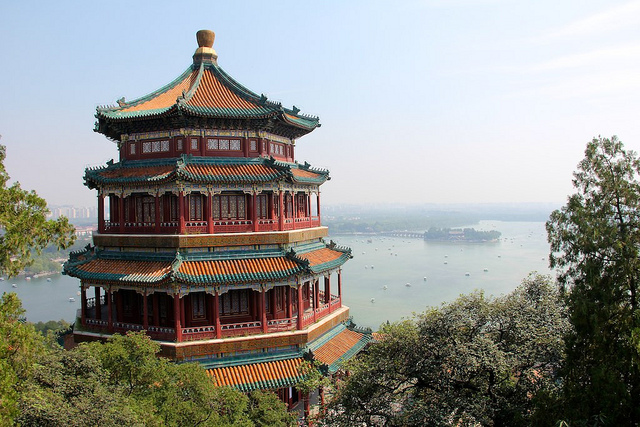

In [15]:
china

array([[[ 2, 19, 13],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 1, 77, 64],
        [ 0, 76, 64],
        [ 0, 75, 63]],

       [[ 1, 18, 12],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 0, 76, 64],
        [ 1, 74, 65],
        [ 1, 74, 65]],

       [[ 2, 17, 12],
        [ 6, 19, 12],
        [ 7, 20, 13],
        ...,
        [ 1, 74, 65],
        [ 1, 74, 67],
        [ 1, 74, 67]],

       ...,

       [[ 0, 46, 40],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 5, 44, 26],
        [ 6, 43, 26],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 6, 45, 27],
        [ 7, 44, 27],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 0, 46, 36],
        ...,
        [ 7, 46, 28],
        [ 8, 45, 28],
        [ 9, 43, 27]]], dtype=uint8)
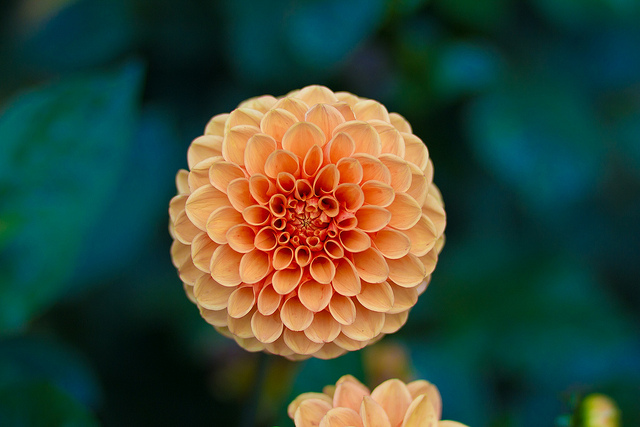

In [16]:
flower

In [17]:
china.shape

(427, 640, 3)

In [21]:
#Resize the image
preprocess_steps = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((300,300)),
    transforms.RandomRotation(50),
    transforms.CenterCrop(200),
    transforms.Grayscale(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5],std=[0.5])
    ])

x = preprocess_steps(flower)
print(x.shape)
x

torch.Size([1, 200, 200])


tensor([[[-0.8275, -0.8275, -0.8196,  ..., -0.6000, -0.6078, -0.6157],
         [-0.8353, -0.8353, -0.8353,  ..., -0.5922, -0.6000, -0.6078],
         [-0.8353, -0.8431, -0.8353,  ..., -0.5922, -0.5922, -0.6000],
         ...,
         [-0.8824, -0.8824, -0.8902,  ..., -0.6392, -0.6471, -0.6627],
         [-0.8824, -0.8902, -0.8902,  ..., -0.6392, -0.6471, -0.6549],
         [-0.8824, -0.8824, -0.8902,  ..., -0.6078, -0.6314, -0.6314]]])

In [23]:
x.mean(), x.std()

(tensor(-0.2884), tensor(0.4799))

### Concrete Crack Images - Binary Image classification Model

In [2]:
!wget https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/5y9wdsg2zt-2.zip
!unzip 5y9wdsg2zt-2.zip
!unrar x -idq "/content/Concrete Crack Images for Classification.rar"

--2025-05-06 13:30:17--  https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/5y9wdsg2zt-2.zip
Resolving prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)... 3.5.68.71, 3.5.71.137, 3.5.71.60, ...
Connecting to prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)|3.5.68.71|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 240847944 (230M) [application/octet-stream]
Saving to: ‘5y9wdsg2zt-2.zip’

5y9wdsg2zt-2.zip    100%[===================>] 229.69M  17.5MB/s    in 14s     

2025-05-06 13:30:32 (16.2 MB/s) - ‘5y9wdsg2zt-2.zip’ saved [240847944/240847944]

Archive:  5y9wdsg2zt-2.zip
  inflating: Concrete Crack Images for Classification.rar  


In [3]:
#!/usr/bin/env python3
"""
split_dataset.py  —  Move images from Positive/ Negative/ into

    train/Positive   (15 000 files)
    train/Negative
    test/Positive    (remaining 5 000)
    test/Negative

Assumes the script is run from the directory that currently contains
Positive/ and Negative/.  Edit POS_DIR, NEG_DIR, or TRAIN_COUNT if
your layout is different.

Usage:  python split_dataset.py
"""

import os
import random
import shutil

# ----------------------------------------------------------------------
# Config – change only if you need to
# ----------------------------------------------------------------------
POS_DIR      = "Positive"
NEG_DIR      = "Negative"
TRAIN_COUNT  = 15_000          # files per class that go into train/
RANDOM_SEED  = 42              # make the split reproducible
# ----------------------------------------------------------------------

random.seed(RANDOM_SEED)

def split_class(src_dir: str):
    """Move TRAIN_COUNT random files from *src_dir* to train/src_dir
       and the remainder to test/src_dir."""
    # 1️⃣  Collect every regular file in this class
    all_files = [
        f for f in os.listdir(src_dir)
        if os.path.isfile(os.path.join(src_dir, f))
    ]
    if len(all_files) < TRAIN_COUNT:
        raise RuntimeError(
            f"{src_dir} has only {len(all_files)} files — need at least {TRAIN_COUNT}"
        )

    # 2️⃣  Shuffle deterministically
    random.shuffle(all_files)

    train_files = all_files[:TRAIN_COUNT]
    test_files  = all_files[TRAIN_COUNT:]

    # 3️⃣  Ensure target folders exist
    train_target = os.path.join("train",  src_dir)
    test_target  = os.path.join("test",   src_dir)
    os.makedirs(train_target, exist_ok=True)
    os.makedirs(test_target,  exist_ok=True)

    # 4️⃣  Move the files
    for fname in train_files:
        shutil.move(os.path.join(src_dir, fname),
                    os.path.join(train_target, fname))

    for fname in test_files:
        shutil.move(os.path.join(src_dir, fname),
                    os.path.join(test_target, fname))

    # 5️⃣  Quick report
    print(f"{src_dir}: {len(train_files)} → train/, {len(test_files)} → test/")

def main():
    split_class(POS_DIR)
    split_class(NEG_DIR)

    # Sanity check
    tot_train = sum(len(files) for _, _, files in os.walk("train"))
    tot_test  = sum(len(files) for _, _, files in os.walk("test"))
    print(f"\nDone.  Train set: {tot_train} files   |   Test set: {tot_test} files")

main()

Positive: 15000 → train/, 5000 → test/
Negative: 15000 → train/, 5000 → test/

Done.  Train set: 30000 files   |   Test set: 10000 files


In [10]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

In [5]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5),std=(0.5))
])

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [7]:
batch_size = 4
trainset = torchvision.datasets.ImageFolder(root="/content/train",transform=transform)
testset = torchvision.datasets.ImageFolder(root="/content/test",transform=transform)

train_loader = DataLoader(trainset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(testset,batch_size=batch_size,shuffle=True)

In [8]:
# Show images
def imshow(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1,2,0)))
  plt.show()

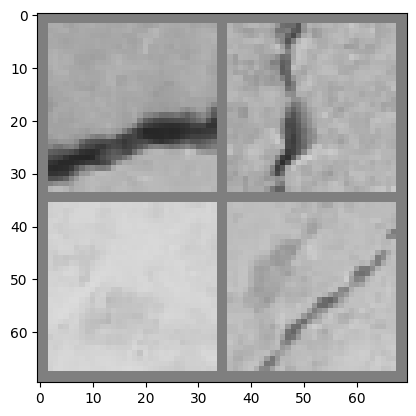

In [11]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images,nrow=2))

In [12]:
images[0].shape

torch.Size([1, 32, 32])

In [13]:
class ImageClassifierNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1,6,3) # out: batch_size, 6, 30, 30
    self.pool = nn.MaxPool2d(2,2) # out: batch_size, 6, 15, 15
    self.conv2 = nn.Conv2d(6,16,3) # out: batch_size, 16, 13, 13
    self.fc1 = nn.Linear(16*6*6, 128) # after next pool: batch_size, 16, 6, 6
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64,1)
    self.sigmoid = nn.Sigmoid()
    self.relu = nn.ReLU()

  def forward(self,x):
    x = self.conv1(x) # out: batch_size, 6, 30, 30
    x = self.relu(x)
    x = self.pool(x) # out: batch_size, 6, 15, 15
    x = self.conv2(x) # out: batch_size, 16, 13, 13
    x = self.relu(x)
    x = self.pool(x) # after next pool: batch_size, 16, 6, 6
    x = torch.flatten(x,1) # out: batch_size, 16, 6, 6
    x = self.fc1(x) # out: batch_size, 128
    x = self.relu(x)
    x = self.fc2(x) # out: batch_size, 64
    x = self.relu(x)
    x = self.fc3(x) # out: batch_size, 1
    x = self.sigmoid(x)
    return x

In [17]:
model = ImageClassifierNet().to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001,momentum=0.8)

In [18]:
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
  losses = 0
  for i, data in enumerate(train_loader):
    input, label = data
    optimizer.zero_grad()
    y_pred = model(input.to(device))
    loss = loss_fn(y_pred, label.reshape(-1,1).float().to(device))
    loss.backward()
    optimizer.step()
    losses += loss
  print(f"epochs {epoch}, Loss: {losses}")

epochs 0, Loss: 2800.76171875
epochs 1, Loss: 438.5718078613281
epochs 2, Loss: 365.9621276855469
epochs 3, Loss: 346.32427978515625
epochs 4, Loss: 329.87548828125
epochs 5, Loss: 317.8821716308594
epochs 6, Loss: 306.5513610839844
epochs 7, Loss: 298.1143493652344
epochs 8, Loss: 286.43212890625
epochs 9, Loss: 279.99627685546875


In [20]:
# %% test
y_test = []
y_test_hat = []
for i, data in enumerate(test_loader, 0):
    inputs, y_test_temp = data
    with torch.no_grad():
        y_test_hat_temp = model(inputs.to(device)).round()

    y_test.extend(y_test_temp.numpy())
    y_test_hat.extend(y_test_hat_temp.to("cpu").numpy())

# %%
acc = accuracy_score(y_test, y_test_hat)
print(f'Accuracy: {acc*100:.2f} %')

Accuracy: 98.92 %


### Layer calculation

In [21]:
import torch
import torch.nn as nn

In [22]:
input = torch.rand((1,3,32,32))
input.shape

torch.Size([1, 3, 32, 32])

In [33]:
model = nn.Sequential(
    nn.Conv2d(3,8,3))

model(input).shape

torch.Size([1, 8, 30, 30])

In [34]:
model = nn.Sequential(
    nn.Conv2d(3,8,3),
    nn.MaxPool2d(2,2))

model(input).shape

torch.Size([1, 8, 15, 15])

In [35]:
model = nn.Sequential(
    nn.Conv2d(3,8,3),
    nn.MaxPool2d(2,2),
    nn.Conv2d(8,16,3))

model(input).shape

torch.Size([1, 16, 13, 13])

In [36]:
model = nn.Sequential(
    nn.Conv2d(3,8,3),
    nn.MaxPool2d(2,2),
    nn.Conv2d(8,16,3),
    nn.MaxPool2d(2,2))

model(input).shape

torch.Size([1, 16, 6, 6])

In [38]:
model = nn.Sequential(
    nn.Conv2d(3,8,3),
    nn.MaxPool2d(2,2),
    nn.Conv2d(8,16,3),
    nn.MaxPool2d(2,2),
    nn.Flatten())

model(input).shape

torch.Size([1, 576])

In [39]:
model = nn.Sequential(
    nn.Conv2d(3,8,3),
    nn.MaxPool2d(2,2),
    nn.Conv2d(8,16,3),
    nn.MaxPool2d(2,2),
    nn.Flatten(),
    nn.Linear(576,128))

model(input).shape

torch.Size([1, 128])